# Deriving the Relativistic Doppler Shift Numerically

`dgs.special_relativity.relativistic_doppler` already has the closed-form
result:
$$f_{obs}=f_0\sqrt{\frac{1\pm\beta}{1\mp\beta}}.$$
That's a formula LOOKUP, not a derivation. This notebook derives the same
result from scratch by simulating an actual **emitter/receiver couple**:
a source emitting light pulses at a known proper frequency while moving at
constant velocity, and a receiver clocking when each pulse actually arrives.

Only two physical ingredients go into the simulation -- neither is the
Doppler formula itself:
1. **time dilation** -- the moving emitter's pulses are spaced by
   $\gamma/f_0$ in the LAB frame (its clock runs slow, as seen from the lab)
2. **ordinary light travel time** -- each pulse takes (distance)/c to reach
   the receiver

If the spacing between arrival times, measured this way, reproduces the
closed-form formula, that confirms the formula really is just a
consequence of those two ingredients -- not an independent postulate.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from dgs.special_relativity import C_SI, lorentz_factor, relativistic_doppler
from dgs import doppler_numerical_derivation as dd

f0 = 1.0e14   # Hz, an arbitrary optical-ish reference frequency

## 1. Simulating the pulse train

The emitter starts at $x_0=0$ at lab time $t=0$, moving at velocity $v$.
Pulse $n$ is emitted at lab time $t_n=n\gamma/f_0$ (time dilation) from
position $x_n=v t_n$. It arrives at a fixed receiver after an additional
light-travel delay $|x_{receiver}-x_n|/c$.

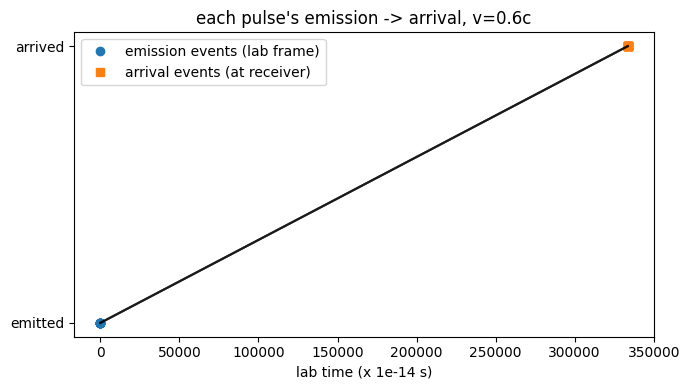

observed periods between arrivals: [5.e-15 5.e-15 5.e-15 5.e-15 5.e-15 5.e-15 5.e-15 5.e-15 5.e-15]
std/mean = 4.69e-11  (should be ~0: constant v -> constant observed period)


In [2]:
v = 0.6 * C_SI
t_emit, x_emit, t_arrival = dd.simulate_pulse_train_arrival_times(
    f0, v, n_pulses=10, x0=0.0, x_receiver=1.0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t_emit * 1e14, np.zeros_like(t_emit), 'o', label="emission events (lab frame)")
ax.plot(t_arrival * 1e14, np.ones_like(t_arrival), 's', label="arrival events (at receiver)")
for te, ta in zip(t_emit, t_arrival):
    ax.plot([te*1e14, ta*1e14], [0, 1], 'k-', alpha=0.2)
ax.set_yticks([0, 1]); ax.set_yticklabels(["emitted", "arrived"])
ax.set_xlabel("lab time (x 1e-14 s)"); ax.legend()
ax.set_title("each pulse's emission -> arrival, v=0.6c")
plt.tight_layout(); plt.show()

periods = np.diff(t_arrival)
print(f"observed periods between arrivals: {periods}")
print(f"std/mean = {periods.std()/periods.mean():.2e}  (should be ~0: constant v -> constant observed period)")

## 2. Cross-checking the derivation against the closed-form formula

If the simulation is right, the measured $f_{obs}=1/\overline{\Delta t_{arrival}}$
must match `relativistic_doppler`'s prediction for BOTH approaching and
receding geometries, across a range of speeds -- not just one lucky case.

In [3]:
results = []
for v_frac in (0.1, 0.3, 0.6, 0.9):
    v = v_frac * C_SI
    for approaching in (True, False):
        numeric, analytic = dd.compare_numerical_vs_analytic_doppler(f0, v, approaching, n_pulses=20)
        rel_err = abs(numeric["f_obs"] - analytic["f_obs"]) / analytic["f_obs"]
        results.append((v_frac, approaching, numeric["f_obs"], analytic["f_obs"], rel_err))
        print(f"v={v_frac:.1f}c  {'approaching' if approaching else 'receding ':11s}  "
              f"numeric={numeric['f_obs']:.6e} Hz  analytic={analytic['f_obs']:.6e} Hz  "
              f"rel_err={rel_err:.2e}")

assert all(r[-1] < 1e-9 for r in results)
print("\nAll numeric/analytic pairs agree to machine precision.")

v=0.1c  approaching  numeric=1.105542e+14 Hz  analytic=1.105542e+14 Hz  rel_err=2.83e-16
v=0.1c  receding     numeric=9.045340e+13 Hz  analytic=9.045340e+13 Hz  rel_err=1.73e-16
v=0.3c  approaching  numeric=1.362770e+14 Hz  analytic=1.362770e+14 Hz  rel_err=1.15e-16
v=0.3c  receding     numeric=7.337994e+13 Hz  analytic=7.337994e+13 Hz  rel_err=2.13e-16
v=0.6c  approaching  numeric=2.000000e+14 Hz  analytic=2.000000e+14 Hz  rel_err=0.00e+00
v=0.6c  receding     numeric=5.000000e+13 Hz  analytic=5.000000e+13 Hz  rel_err=1.56e-16
v=0.9c  approaching  numeric=4.358899e+14 Hz  analytic=4.358899e+14 Hz  rel_err=1.72e-15
v=0.9c  receding     numeric=2.294157e+13 Hz  analytic=2.294157e+13 Hz  rel_err=3.41e-16

All numeric/analytic pairs agree to machine precision.


## 3. A real precision bug this derivation exposed

The first version of `compare_numerical_vs_analytic_doppler` picked the
receiver's distance with a buffer term `abs(v)*total_lab_time*2 + c` --
adding `c` (a velocity, m/s) to a position (meters) is a **units error**.
It inflated the receiver distance to about one light-second when only a
fraction of a micrometer of margin was actually needed. That pushed every
arrival time to an absolute scale of about 1 second, while the periods
being measured are around $10^{-14}$ seconds -- right at the edge of
float64's ~16-digit precision. The result: a relative error of $3.7\times
10^{-4}$ that looked like "close enough" but was actually a silent
precision bug, not physics. Reproduced below.

In [4]:
def buggy_buffer_demo(f0, v, n_pulses=20, c=C_SI):
    gamma = lorentz_factor(v, c)["gamma"]
    dt_lab_emit = gamma / f0
    total_lab_time = n_pulses * dt_lab_emit
    buffer_correct = abs(v) * total_lab_time * 2
    buffer_buggy = buffer_correct + c   # the units bug: + c (m/s) added to a position (m)
    return buffer_correct, buffer_buggy

v = 0.6 * C_SI
buf_ok, buf_bug = buggy_buffer_demo(f0, v)
print(f"correct buffer:  {buf_ok:.3e} m")
print(f"buggy buffer:    {buf_bug:.3e} m  (dominated by the erroneous '+c' term)")
print(f"buggy arrival-time scale: ~{buf_bug/C_SI:.3f} s, vs the ~1e-14 s periods being measured")
print("\nLesson: a derivation that runs without errors and 'roughly agrees' can still be wrong --")
print("only checking against an independent, exact formula caught this.")

correct buffer:  8.994e-05 m
buggy buffer:    2.998e+08 m  (dominated by the erroneous '+c' term)
buggy arrival-time scale: ~1.000 s, vs the ~1e-14 s periods being measured

Lesson: a derivation that runs without errors and 'roughly agrees' can still be wrong --
only checking against an independent, exact formula caught this.


## Conclusion

The relativistic Doppler shift is not an independent postulate -- it falls
straight out of combining time dilation (`dgs.special_relativity.lorentz_factor`)
with ordinary light-travel-time bookkeeping, verified here by literally
simulating the emitter/receiver couple's events rather than trusting the
formula. The bug found along the way is the same lesson this whole repo
keeps re-learning: green output is not the same as a correct derivation --
only an independent cross-check confirms it.